In [1]:
## Importing Libararries 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("Online_Retail.csv", encoding="latin1",on_bad_lines="skip",sep="\t")

In [4]:
df.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/01/2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/01/2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/01/2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/01/2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/01/2010 08:34,1.69,13047.0,United Kingdom


In [5]:
## Exploring the dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
## Convert Types

In [8]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [9]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [10]:
df=df.dropna(subset=['CustomerID'])

In [11]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [12]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int32
Country                object
dtype: object

In [13]:
## Removing Canceled Invoices

In [14]:
df=df[~df["InvoiceNo"].astype(str).str.startswith('C')]

In [15]:
df["InvoiceNo"].astype(str).str.startswith('C').sum()

0

In [16]:
## Calculating Total Price for each Invoice

In [17]:
df = df[df["Quantity"] > 0]

In [18]:
df['Total_Price'] = df['Quantity'] * df['UnitPrice']

In [19]:
df.Total_Price

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: Total_Price, Length: 397924, dtype: float64

In [20]:
df.head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08


In [21]:
## Assignning A referevce date for Recency one day after last date 

In [22]:
ref_date=df["InvoiceDate"].max()+pd.Timedelta(days=1)

In [23]:
ref_date

Timestamp('2011-12-10 12:50:00')

In [24]:
## Group Customers according Recency , Frequency and Monetary

In [25]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,  
    'InvoiceNo': 'nunique',                                   
    'Total_Price': 'sum'                                       
}).reset_index()
rfm.columns = ["CustomeID" , "Recency" , "Frequency" , "Monetary"]
rfm

,CustomeID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
...,...,...,...,...
4334,18280,278,1,180.60
4335,18281,181,1,80.82
4336,18282,8,2,178.05
4337,18283,4,16,2094.88


In [26]:
## Assignning Scores to Customers

In [27]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [28]:
rfm

,CustomeID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112
...,...,...,...,...,...,...,...,...
4334,18280,278,1,180.60,1,2,1,121
4335,18281,181,1,80.82,1,2,1,121
4336,18282,8,2,178.05,5,3,1,531
4337,18283,4,16,2094.88,5,5,5,555


In [29]:
## Group Similar Customers according their RFM Score

In [30]:
similar_customers = rfm['RFM_Score'].value_counts().reset_index()
similar_customers.columns = ['RFM_Score', 'Customers']

In [31]:
similar_customers

,RFM_Score,Customers
0,555,348
1,111,182
2,455,178
3,121,154
4,112,128
...,...,...
113,414,1
114,415,1
115,152,1
116,525,1


In [42]:
Revenue_by_country = df.groupby(["Country"])["Total_Price"].sum().reset_index().head(10)

In [50]:
Revenue_by_country.columns=["Country" , "Revenue"]
Revenue_by_country = Revenue_by_country.sort_values(by="Revenue")

<Axes: xlabel='Revenue', ylabel='Country'>

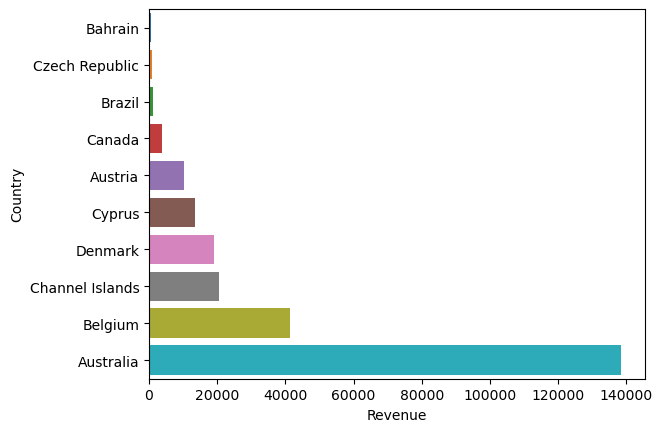

In [63]:
sns.barplot(data=Revenue_by_country , y = "Country" , x="Revenue")

In [58]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

Revenue_Trend = df.groupby(["Year", "Month"])["Total_Price"].sum().reset_index()

In [59]:
Revenue_Trend

,Year,Month,Total_Price
0,2010,12,572713.890
1,2011,1,569445.040
2,2011,2,447137.350
3,2011,3,595500.760
4,2011,4,469200.361
5,2011,5,678594.560
6,2011,6,661213.690
7,2011,7,600091.011
8,2011,8,645343.900
9,2011,9,952838.382


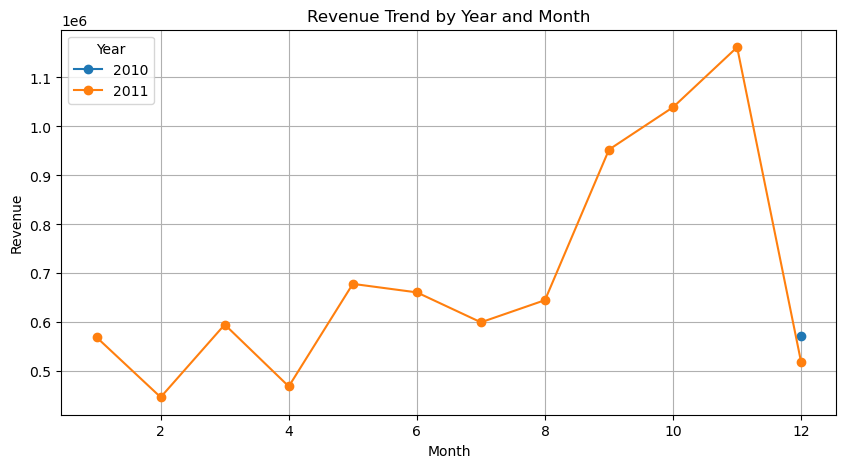

In [61]:
pivot = Revenue_Trend.pivot(index="Month", columns="Year", values="Total_Price")
pivot.plot(marker="o", figsize=(10,5))

plt.title("Revenue Trend by Year and Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()